## LLM-enhanced Linux Kernel Profiling/Enhancement

### Background

We want to know the benign kernel-level behaviors (a set of benign kernel functions) of each syscall.

We propose hybrid program analysis --- it combines dynamic profiling (which captures actual executed paths but may miss unexecuted flows) with static call graph analysis (which reveals all potential calls but often over-approximates) [1].

In complex software (e.g. OS kernels), dynamic call graphs can be under-approximated – many legitimate call edges remain unseen because the inputs or execution did not trigger them. 
Pure static analysis, on the other hand, may introduce spurious edges that are infeasible at runtime (false positives). 

The goal is to bridge this gap by expanding the dynamic call graph with likely edges suggested by static analysis, while filtering out unrealistic ones. Large Language Models (LLMs) can serve as semantic reasoners in this context. 

An LLM can assess whether a candidate static call edge (a function $L$ calling a function $x$) is plausible given: 
- (1) the current observed call graph context, 
- (2) the call path leading to $L$ (i.e. how the program reached $L$), and 
- (3) the *semantics and signatures* of both $L$ and $x$. 

By understanding code semantics and intent (learned from vast code corpora), the LLM can infer if, for example, function $L$ (say, a resource initializer) would logically invoke function $x$ (perhaps a resource finalizer or related helper) in that context. 
This semantic filtering helps eliminate static edges that don't make sense, reducing false positives while recovering missed edges that a pure dynamic profile didn’t cover. 
Prior work has shown the promise of LLMs in similar roles – e.g. using code summaries to match indirect call targets [2] or to prune static analysis false positives by asking about expected function behavior [1]. 
The key insight is that LLMs can interpret high-level semantic cues (function names, documentation, code comments, etc.) to validate control-flow relationships that purely syntax-based analyses might miss [3].

> [1] Poster: Assisting Static Analysis with Large Language Models: A ChatGPT Experiment (S\&P)
> 
> [2] Semantic-Enhanced Indirect Call Analysis with Large Language Models (arxiv)
>
> [3] https://github.com/247arjun/ai-static-analysis-pipeline/blob/main/Elevating%20Code%20Security%20and%20Reliability%20via%20LLM-Augmented%20Static%20Analysis.md


In [1]:
%load_ext autoreload
%autoreload 2
import networkx as nx
import matplotlib.pyplot as plt
import os
import scipy
from kfunc_filter import should_filter_function

First of all, we have to load the static kernel call graph.

In [2]:
kernel_cg_path = "./callgraph.graphml"
k_cg = nx.read_graphml(kernel_cg_path)

# prune self-loops
k_cg.remove_edges_from(nx.selfloop_edges(k_cg))

In this CallGraph (CG), each node is a *function name*, and each edge (u, v) denotes a *call relation* u (caller) -> v (callee).

For a single node u1, it may has different call targets (let's say {v1, v2, ..., vn}).

- If function u1 has indirect calls (u1 as the callsite), then it will has `u1.has_indirect = True`.
- If function u1 has indirect call targets, for each edge {(u1, v1), (u1, v2), ...}, the indirect call edge will have property `indirect = True`

See the demonstrated `describe_node` below.

In [3]:
def describe_node(graph, node):
    if node not in graph:
        print(f"Node {node} does not exist in the graph.")
        return

    print(f"Node: {node}")
    print(f"Has indirect calls: {graph.nodes[node].get('has_indirect', False)}")

    print("Outgoing edges:")
    for _, target, edge_data in graph.out_edges(node, data=True):
        indirect = edge_data.get('indirect', False)
        print(f"  {node} -> {target:<20} (is indirect call: {indirect})")

Read this kernel function (`filp_close`) source code:
```c
int filp_close(struct file *filp, fl_owner_t id)
{
	int retval = 0;

	if (!file_count(filp)) {
		printk(KERN_ERR "VFS: Close: file count is 0\n");
		return 0;
	}

	if (filp->f_op->flush)
		retval = filp->f_op->flush(filp, id);

	if (likely(!(filp->f_mode & FMODE_PATH))) {
		dnotify_flush(filp, id);
		locks_remove_posix(filp, id);
	}
	fput(filp);
	return retval;
}
```

From the source code, you can see it has several direct calls:
```
filp_close -> printk
filp_close -> dnotify_flush
filp_close -> locks_remove_posix
filp_close -> fput
```

And it has indirect call: `filp_close -> filp->f_op->flush()`.

In [4]:
# This u1 ("filp_close") is a node with indirect calls
describe_node(k_cg, "filp_close")

Node: filp_close
Has indirect calls: True
Outgoing edges:
  filp_close -> _printk              (is indirect call: False)
  filp_close -> dnotify_flush        (is indirect call: False)
  filp_close -> fput                 (is indirect call: False)
  filp_close -> locks_remove_posix   (is indirect call: False)
  filp_close -> mqueue_flush_file    (is indirect call: True)
  filp_close -> nfs4_file_flush      (is indirect call: True)
  filp_close -> nfs_file_flush       (is indirect call: True)


In [5]:
# This u2 ("__x64_sys_close") is a node without indirect calls. 
# This is the entry function of a syscall `close`.
describe_node(k_cg, "__x64_sys_close")

Node: __x64_sys_close
Has indirect calls: False
Outgoing edges:
  __x64_sys_close -> close_fd             (is indirect call: False)


### 1. Ask LLM to generate per-function summary

LLMs have been proven to show good performance of understanding code semantics and summarizing the behavior of functions [1-3].
> [1] Large Language Models for Code Analysis: Do LLMs Really Do Their Job? (Usenix Security'24)
>
> [2] kernelGPT: Enhanced Kernel Fuzzing via Large Language Models (ASPLOS'25)
>
> [3] Exploiting Code Symmetries for Learning Program Semantics (arxiv)

In this work, we would use Qwen3-32B (https://huggingface.co/Qwen/Qwen3-32B) (or any other state-of-the-art code LLM).


For every individual function, we need to request LLM to summarize its semantics, include the function definitions and behaviors.

**Input**: function source code (e.g., the above `filp_close` source code).

**Output**: function prototype and code semantics summary.

Here is demonstrated prompts:

**Prompt0**:
I will input Linux kernel function source code. Please read the source code and summarize its behavior.
My input: function definition and source code.
Your output:
```
{
   "func_name": input function, 
   "signature": its argument types and return value types,
   "summary": its behavior (within X words),
}.
```
**Prompt1:** filp_close {source code}

**Answer1:** 
```
{
   "func_name": "filp_close",
   "signature": "args: {struct file *, fl_owner_t}, ret: {int}",
   "source code": {...},
   "summary": "Closes a file descriptor by performing flush operations, removing file notifications, releasing POSIX locks, and decrementing the file reference count. Returns the result of the flush operation if implemented."
}
```

In [6]:
# Here are all kernel functions in the call graph
# You only need to consider functions that are not filtered out
# (we filter functions if they are related to interrupt handlers/context switches)

kall_functions = [node for node in k_cg.nodes if not should_filter_function(node)]
print(f"Total kernel functions (after filtering): {len(kall_functions)}/{len(k_cg.nodes)}")

Total kernel functions (after filtering): 41879/45596


### 2. Ask LLM to enhance our dynamic profile

A dynamic profile contains all performs benign behaviors (of a syscall) during our certain workloads. It would absolutely under-approximate the potential behaviors of that syscall.

We will input the dynamic profile into LLM to let it enlarge possible benign behaviors, by analyzing the code semantics and contexts.

**Some useful functionalities:**
- Generate a dynamic call graph (subgraph) from profiles
- Traverse a graph from a node (see its out edges)

In [7]:
# def gen_subgraph(static_graph, sys_entry_function, function_set, remove_broken_edges=False):
#     """
#     Generate a dynamic call graph for a given function (by using a static callgraph).
    
#     :remove_broken_edges: 
#     In some cases, the call graph may contain nodes with no in-degrees (islands that are not resolved by static callgraph).
#     If True, remove nodes with no in-degrees except for the sys_entry_function.
#     """
#     function_set = [f for f in function_set if not should_filter_function(f)]
    
#     # filter out nodes in should_filter_function before intersection
#     reachable_nodes = nx.descendants(static_graph, sys_entry_function).intersection(function_set)
#     reachable_nodes.add(sys_entry_function)  # Include the entry function itself
    
#     subgraph = static_graph.subgraph(reachable_nodes).copy()  # Create a copy to preserve attributes
    
#     if remove_broken_edges:
#         # Iteratively remove nodes with no in-degrees except for the sys_entry_function
#         nodes_to_remove = [node for node in subgraph if subgraph.in_degree(node) == 0 and node != sys_entry_function]
#         while nodes_to_remove:
#             subgraph.remove_nodes_from(nodes_to_remove)
#             # print(f"Removed nodes: {nodes_to_remove}")
#             nodes_to_remove = [node for node in subgraph if subgraph.in_degree(node) == 0 and node != sys_entry_function]
    
#     return subgraph

In [8]:
def gen_subgraph(static_graph, sys_entry_function, function_set, remove_broken_edges=False):
    """
    sys_enter_function is useful only when remove_broken_edges is True.
    """
    # Filter nodes to include only those in the function_set
    function_set = [f for f in function_set if not should_filter_function(f)]
    subgraph_nodes = set(function_set)

    if remove_broken_edges:
        # Find all reachable nodes from the sys_entry_function
        reachable_nodes = nx.descendants(static_graph, sys_entry_function)
        reachable_nodes.add(sys_entry_function)  # Include the entry function itself
        subgraph_nodes = subgraph_nodes.intersection(reachable_nodes)

    # Create the subgraph with the filtered nodes
    subgraph = static_graph.subgraph(subgraph_nodes).copy()
    return subgraph

In [9]:
def outedges_callgraph(graph, function_name, do_filter=True):
    """ 
    function_name is the source node (u), it will return all out-edges (u, v1), (u, v1),... of this node.
    """
    if function_name not in graph:
        print(f"Function {function_name} does not exist in the graph.")
        return []

    out_edges = []
    for _, target, edge_data in graph.out_edges(function_name, data=True):
        if do_filter and should_filter_function(target):
            continue
        out_edges.append((function_name, target, edge_data))
    
    return out_edges

In [10]:
def draw_subgraph(graph, graph_name):
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(graph)  # Use the graph layout
    in_degree_zero_nodes = [node for node in graph if graph.in_degree(node) == 0]
    node_colors = ['red' if node in in_degree_zero_nodes else 'lightblue' for node in graph.nodes]
    nx.draw(graph, pos, with_labels=True, node_size=500, font_size=10, node_color=node_colors, edge_color='black')
    print(f"Subgraph number of nodes: {len(graph.nodes())}, number of edges: {len(graph.edges())}")
    plt.title(f"Subgraph: {graph_name}")
    plt.show()


Now, we will draw a purely dynamic graph (starting from `__x64_sys_close`, by using the profile of `close` syscall).

Subgraph number of nodes: 6, number of edges: 5


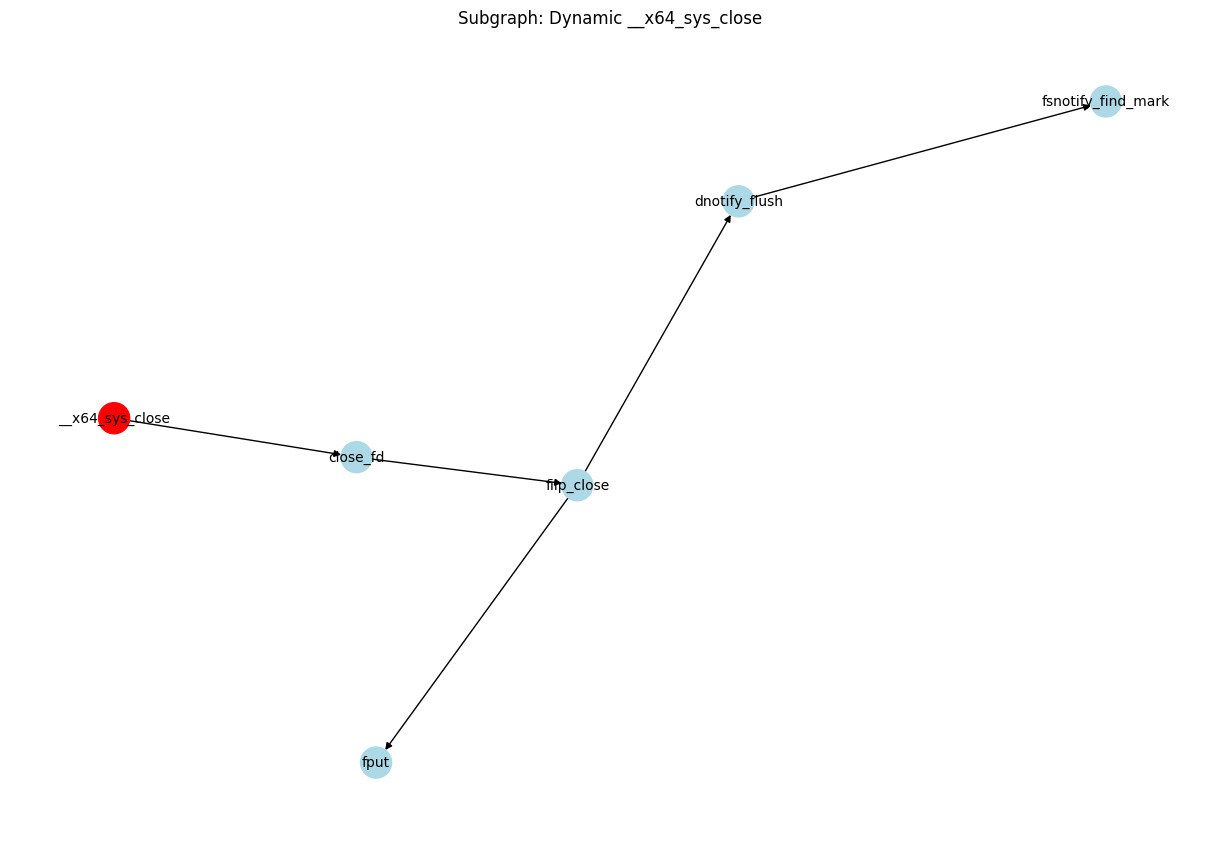

In [11]:
# Let's play with a demo profile for now
demo_profile = "./demo-profile-sysclose.txt"

# extract all functions in that profiles
demo_profiled_functions = set()

with open(demo_profile, "r") as f:
    lines = f.readlines()
    for line in lines:
        func_name = line.strip()
        if func_name in kall_functions and not should_filter_function(func_name):
            demo_profiled_functions.add(func_name)
    
# generate the dynamic call graph as its contextual information
# Extract the subgraph containing only the demo_profiled_functions
subgraph = gen_subgraph(k_cg, "__x64_sys_close", demo_profiled_functions)

# Draw the subgraph
draw_subgraph(subgraph, "Dynamic __x64_sys_close")

Now, we will also see the statistics of the static callgraph of `close` syscall (starting from `__x64_sys_close`).

In [ ]:
# kall_functions contains all kernel functions (not filtered)
"_raw_spin_lock" in kall_functions

kfiltered_functions = [f for f in kall_functions if should_filter_function(f)]

In [ ]:
describe_node(k_cg, "filp_close")

In [ ]:
out_edges = outedges_callgraph(k_cg, "llist_add_batch")
for src, dst, edge_data in out_edges:
    print(f"Source: {src}, Target: {dst}, Edge data: {edge_data}")